# Validación del baseline Fire Weather Index (CEMS)

Este cuaderno valida `fire_weather_index`, el baseline físico de CEMS/EFFIS incorporado al datacubo. El índice describe peligro meteorológico de incendio, no igniciones observadas. Su resolución original es 0,25° y se asigna por vecino más cercano a las celdas de 1 km, como en IberFire.

Antes de ejecutarlo, reconstruye el producto canónico con `python -m src.workflow ...` para que el NetCDF incluya FWI.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np
import pandas as pd
import xarray as xr

def find_project_root(start: Path) -> Path:
    """Encuentra la raíz aunque PyCharm ejecute desde notebooks/."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'data').is_dir():
            return candidate
    raise FileNotFoundError('No se ha localizado la raíz del repositorio.')

ROOT = find_project_root(Path.cwd())
CUBE_PATH = ROOT / 'data/processed/datacube/galicia_1km.nc'
GRID_PATH = ROOT / 'data/processed/grid/galicia_grid_1km.gpkg'
BOUNDARY_PATH = ROOT / 'data/raw/igm/galicia_boundary.geojson'
RAW_FWI_DIR = ROOT / 'data/raw/meteorology/fwi'

assert CUBE_PATH.exists(), f'No se encuentra el datacubo: {CUBE_PATH}'
assert GRID_PATH.exists(), f'No se encuentra la rejilla: {GRID_PATH}'
cube = xr.open_dataset(CUBE_PATH)
if 'fire_weather_index' not in cube:
    raise RuntimeError('El cubo actual no incluye FWI. Ejecuta de nuevo src.workflow sin --skip-fwi.')

grid = gpd.read_file(GRID_PATH)
boundary = gpd.read_file(BOUNDARY_PATH).to_crs(grid.crs)
active = cube['is_galicia'].values.astype(bool)
extent = (float(cube.x.min()) - 500, float(cube.x.max()) + 500,
          float(cube.y.min()) - 500, float(cube.y.max()) + 500)

plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white',
    'font.size': 10, 'axes.titleweight': 'bold', 'axes.spines.top': False,
    'axes.spines.right': False, 'figure.dpi': 120,
})

print(f'Periodo del cubo: {pd.Timestamp(cube.time.min().item()).date()} - {pd.Timestamp(cube.time.max().item()).date()}')
print(f'Celdas activas: {active.sum():,}')
print('Atributos FWI:', dict(cube['fire_weather_index'].attrs))

Periodo del cubo: 2019-01-01 - 2023-11-26
Celdas activas: 29,601
Atributos FWI: {'long_name': 'Canadian Fire Weather Index', 'units': '1', 'source': 'Copernicus CEMS Fire danger indices historical data', 'description': 'Daily physical fire-danger baseline generated by CEMS from ERA5 forcing. It does not represent observed ignitions.', 'time_contract': 'Same-day historical fire-danger index; no temporal shift applied.', 'spatial_interpolation': 'Nearest-neighbour interpolation from the native 0.25 degree CEMS grid to 1 km cells, following the IberFire baseline procedure.'}


## 1. Comprobaciones de cobertura y contrato

FWI debe cubrir todos los días del datacubo desde 2019. Los valores nulos fuera de la máscara son esperados; dentro de Galicia no deben existir.

In [2]:
fwi = cube['fire_weather_index']
assert fwi.sizes['time'] == cube.sizes['time']
assert fwi.notnull().where(cube['is_galicia'] == 1).all()
assert fwi.attrs.get('units') == '1'
assert 'nearest' in fwi.attrs.get('spatial_interpolation', '').lower()

summary = (
    fwi.where(cube['is_galicia'] == 1)
    .to_dataframe(name='FWI')
    .dropna()
    ['FWI'].describe(percentiles=[.01, .25, .5, .75, .99])
)
display(summary.to_frame('FWI'))
print('✓ FWI cubre todas las celdas activas y fechas del datacubo.')

,FWI
count,5.301539e+07
mean,5.344495e+00
std,7.884368e+00
min,1.721502e-09
1%,1.777608e-09
25%,1.919824e-01
50%,1.555579e+00
75%,7.271741e+00
99%,3.323785e+01
max,6.664648e+01


✓ FWI cubre todas las celdas activas y fechas del datacubo.


## 2. FWI original de CEMS y fecha ilustrativa

Se elige el día con mayor número de celdas con ignición EGIF. El primer panel mantiene la resolución original de CEMS; los siguientes muestran la capa ya asignada a la rejilla de 1 km.

Día seleccionado: 2022-07-14 (55 celdas EGIF con ignición)


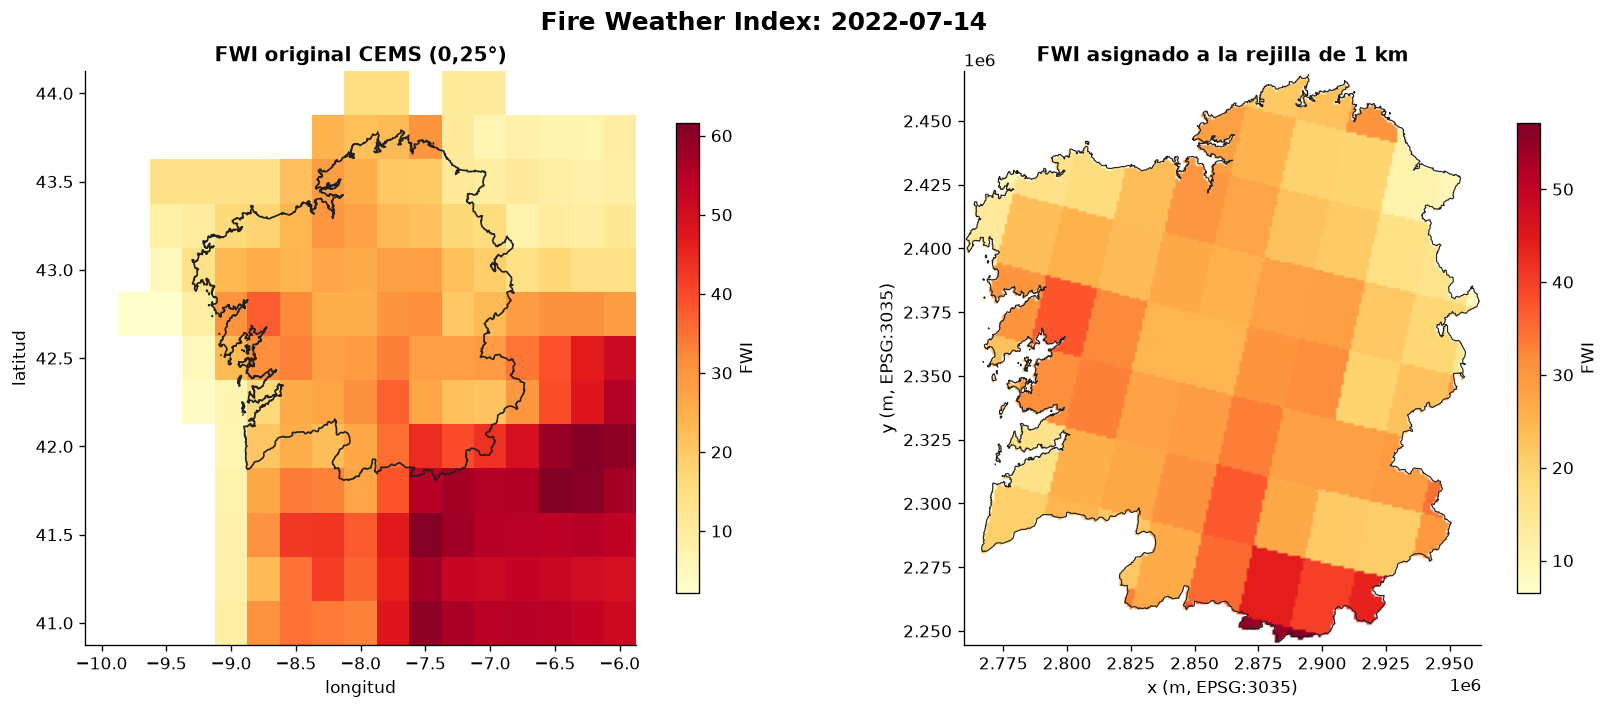

In [3]:
daily_ignitions = cube['target_ignicion'].sum(dim=('y', 'x'))
event_date = pd.Timestamp(daily_ignitions.idxmax().item())
n_ignitions = int(daily_ignitions.max().item())
print(f'Día seleccionado: {event_date.date()} ({n_ignitions} celdas EGIF con ignición)')

raw_files = sorted(RAW_FWI_DIR.glob('fwi_galicia_*.nc'))
assert raw_files, f'No hay NetCDF FWI en {RAW_FWI_DIR}'
raw_parts = [xr.open_dataset(path) for path in raw_files]
try:
    raw = xr.concat(raw_parts, dim='valid_time').sortby('valid_time')
    raw = raw.rename({'valid_time': 'time'})
    raw = raw.assign_coords(longitude=((raw.longitude + 180) % 360) - 180).sortby('longitude')
    raw_day = raw['fwinx'].sel(time=event_date).load()
finally:
    for part in raw_parts:
        part.close()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), constrained_layout=True)
raw_plot = axes[0].pcolormesh(raw_day.longitude, raw_day.latitude, raw_day, cmap='YlOrRd', shading='auto')
boundary_wgs84 = boundary.to_crs('EPSG:4326')
boundary_wgs84.boundary.plot(ax=axes[0], color='#202020', linewidth=1)
axes[0].set(title='FWI original CEMS (0,25°)', xlabel='longitud', ylabel='latitud')
fig.colorbar(raw_plot, ax=axes[0], shrink=.82, label='FWI')

layer = np.ma.masked_where(~active, fwi.sel(time=event_date).values)
grid_plot = axes[1].imshow(layer, origin='lower', extent=extent, cmap='YlOrRd')
boundary.boundary.plot(ax=axes[1], color='#202020', linewidth=.7)
axes[1].set(title='FWI asignado a la rejilla de 1 km', xlabel='x (m, EPSG:3035)', ylabel='y (m, EPSG:3035)')
axes[1].set_aspect('equal')
fig.colorbar(grid_plot, ax=axes[1], shrink=.82, label='FWI')
fig.suptitle(f'Fire Weather Index: {event_date.date()}', fontsize=15, fontweight='bold')
plt.show()

## 3. FWI e igniciones reales

Los puntos representan celdas EGIF con ignición en la fecha elegida. Esta figura es descriptiva: no demuestra causalidad ni evalúa el rendimiento de un modelo.

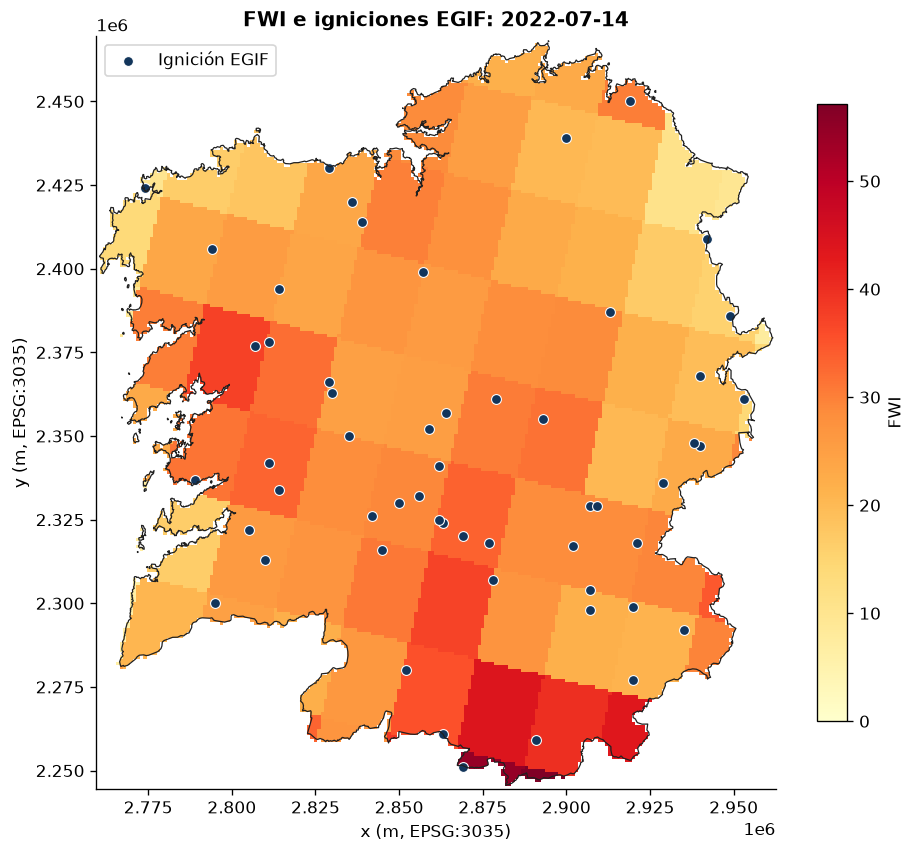

FWI medio en las 55 celdas con ignición: 27.48


In [4]:
fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
image = ax.imshow(layer, origin='lower', extent=extent, cmap='YlOrRd', vmin=0)
fires = cube['target_ignicion'].sel(time=event_date).values == 1
rows, cols = np.where(fires)
ax.scatter(cube.x.values[cols], cube.y.values[rows], s=35, color='#12355b', edgecolor='white',
           linewidth=.65, label='Ignición EGIF')
boundary.boundary.plot(ax=ax, color='#202020', linewidth=.75)
ax.set(title=f'FWI e igniciones EGIF: {event_date.date()}', xlabel='x (m, EPSG:3035)', ylabel='y (m, EPSG:3035)')
ax.set_aspect('equal')
ax.legend(loc='upper left', frameon=True)
plt.colorbar(image, ax=ax, shrink=.82, label='FWI')
plt.show()

fire_values = fwi.sel(time=event_date).values[fires]
print(f'FWI medio en las {len(fire_values)} celdas con ignición: {np.mean(fire_values):.2f}')

## 4. Categorías orientativas y estacionalidad

Las categorías son una ayuda de visualización basada en los umbrales publicados para FWI. No sustituyen la evaluación temporal del modelo de aprendizaje automático.

In [ ]:
thresholds = [0, 5.2, 11.2, 21.3, 38.0, 50.0, np.inf]
labels = ['muy bajo', 'bajo', 'moderado', 'alto', 'muy alto', 'extremo']
colors = ['#d9f0a3', '#addd8e', '#fdae61', '#f46d43', '#d73027', '#7f0000']
category = np.digitize(fwi.sel(time=event_date).values, thresholds[1:-1], right=False)
category_layer = np.ma.masked_where(~active, category)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), constrained_layout=True)
categorical = axes[0].imshow(category_layer, origin='lower', extent=extent,
                            cmap=ListedColormap(colors), norm=BoundaryNorm(range(7), len(colors)))
boundary.boundary.plot(ax=axes[0], color='#202020', linewidth=.7)
axes[0].set(title='Categorías orientativas de FWI', xlabel='x (m, EPSG:3035)', ylabel='y (m, EPSG:3035)')
axes[0].set_aspect('equal')
colorbar = fig.colorbar(categorical, ax=axes[0], ticks=np.arange(6) + .5, shrink=.82)
colorbar.ax.set_yticklabels(labels)

daily_mean = fwi.where(cube['is_galicia'] == 1).mean(dim=('y', 'x')).to_pandas()
monthly_mean = daily_mean.resample('MS').mean()
axes[1].plot(monthly_mean.index, monthly_mean.values, color='#d95f02', linewidth=1.5)
axes[1].fill_between(monthly_mean.index, monthly_mean.values, color='#fdd0a2', alpha=.6)
axes[1].set(title='FWI medio mensual en Galicia', xlabel='fecha', ylabel='FWI medio')
axes[1].grid(axis='y', alpha=.25)
fig.suptitle('Interpretación visual del baseline físico', fontsize=15, fontweight='bold')
plt.show()

## Conclusión de la validación

El índice debe mostrar parches espaciales amplios debido a su resolución de origen, a diferencia de las variables ERA5-Land interpoladas desde una malla más fina. Su función es aportar y evaluar un baseline físico consistente; las decisiones sobre su uso como predictor se toman posteriormente mediante validación temporal de modelos.